## Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.

**TF (term frequency):** How common a genre is inside that community — for example, *grunge* shows up a lot in a grunge cluster.

**IDF (inverse document frequency):** How rare that genre is across all communities. Genres that pop up everywhere (like "rock") get down‑weighted, this means that niche genres that concentrate in one community get up‑weighted.

**TF x IDF:** Highlights genres that are both common within one community and uncommon elsewhere — it's the algorithmic nose that tells you *this cluster smells like glam metal, not just generic rock*.


In [42]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import networkx as nx
import community as louvain
from IPython.display import display

In [43]:
def load_graph_with_genres(path_candidates):
    for p in path_candidates:
        if os.path.exists(p):
            try:
                G = nx.read_graphml(p)
                genres_attr = nx.get_node_attributes(G, "genres")

                if genres_attr:
                    for n, s in genres_attr.items():
                        if isinstance(s, str):
                            genres = [g.strip().lower() for g in s.split(";") if g.strip()]
                            G.nodes[n]["_genres_list"] = genres
                else:
                    base = os.path.splitext(p)[0]
                    json_path = base + "_genres.json"
                    if os.path.exists(json_path):
                        with open(json_path, "r", encoding="utf-8") as f:
                            mapping = json.load(f)
                        for n in G.nodes:
                            genres = mapping.get(n, [])
                            G.nodes[n]["_genres_list"] = [g.strip().lower() for g in genres]
                return G, os.path.basename(p)
            except:
                pass
    return None, None


def compute_communities(G):
    H = G.to_undirected()

    part = louvain.best_partition(H, random_state=15)
    for n, c in part.items():
        G.nodes[n]["community"] = c

    groups = {}
    for n, c in part.items():
        groups.setdefault(c, []).append(n)
    comms = [nodes for _, nodes in sorted(groups.items(), key=lambda x: -len(x[1]))]
    return comms, "louvain"


def build_genre_documents(G, communities):
    docs = []
    for nodes in communities:
        bag = []
        for n in nodes:
            genres = G.nodes[n].get("_genres_list") or []
            bag.extend(genres)
        docs.append(bag)
    return docs


def compute_tfidf(docs):
    N = len(docs)
    vocab = sorted(set(term for doc in docs for term in doc))
    index = {t: i for i, t in enumerate(vocab)}

    tf = np.zeros((N, len(vocab)), dtype=float)
    for d, doc in enumerate(docs):
        counts = Counter(doc)
        total = sum(counts.values())
        for term, c in counts.items():
            tf[d, index[term]] = c / total if total > 0 else 0

    df = np.array([sum(1 for doc in docs if t in doc) for t in vocab])
    idf = np.log((1 + N) / (1 + df)) + 1.0
    tfidf = tf * idf

    return vocab, tfidf, tf, idf, df


def show_heatmap(df_tfidf, top_k=20):
    sums = df_tfidf.sum(axis=0).sort_values(ascending=False)
    keep = sums.head(top_k).index.tolist()
    sub = df_tfidf[keep]

    plt.figure(figsize=(12, 6))
    plt.imshow(sub.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="TF-IDF")
    plt.yticks(range(len(sub.index)), sub.index)
    plt.xticks(range(len(keep)), keep, rotation=45, ha="right")
    plt.title("Top Genres per Community (TF-IDF)")
    plt.show()


def show_top_bars(df_tfidf, top_n=10):
    for comm in df_tfidf.index:
        top = df_tfidf.loc[comm].sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(10, 4))
        plt.bar(top.index, top.values)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} Genres — Community {comm}")
        plt.show()


In [44]:
graph_candidates = ["rock_network_with_genres.graphml"]
G, base_name = load_graph_with_genres(graph_candidates)

if G is None:
    raise FileNotFoundError("⚠️ rock_network_with_genres.graphml not found. Put it next to the notebook.")


In [45]:
communities, method = compute_communities(G)
docs = build_genre_documents(G, communities)
vocab, tfidf, tf, idf, df = compute_tfidf(docs)

comm_labels = list(range(len(communities)))
df_tfidf = pd.DataFrame(tfidf, index=comm_labels, columns=vocab)

✅ TF-IDF complete on: rock_network_with_genres.graphml
Detected 6 communities using louvain.

🎸 Community 0 (150 artists):
Frank Zappa, Mitch Ryder, Bo Diddley, Little Richard, Paul McCartney ...

🎸 Community 1 (147 artists):
Ramones, Pearl Jam, U2, Radiohead, Run-DMC ...

🎸 Community 2 (89 artists):
Ted Nugent, Damn Yankees (band), Skid Row (American band), Pantera, Anthrax (American band) ...

🎸 Community 3 (55 artists):
Stone Temple Pilots, Nickelback, Godsmack, Limp Bizkit, Staind ...

🎸 Community 4 (40 artists):
Styx (band), Foreigner (band), Meat Loaf, Kid Rock, Heart (band) ...

🎸 Community 5 (3 artists):
Parliament (band), Funkadelic, Parliament-Funkadelic



,acid rock,acoustic rock,allmusic,alternative metal,alternative metal art rock shoegaze,alternative metal funk metal alternative rock experimental rock,alternative metal funk metal experimental rock progressive rock,alternative metal gothic metal gothic rock hard rock industrial rock symphonic metal nu metal,alternative metal hard rock,alternative metal hard rock nu metal,...,synth pop,texas blues,the daily aztec,the new york times,thrash metal,thrash metal groove metal,western swing,western/cowboy,worldbeat,yacht rock
0,0.003536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00596,0.000000,0.0,0.000000,0.000000,0.00596,0.00596,0.000000,0.000000
1,0.004739,0.007989,0.000000,0.011061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.031954,0.00000,0.007989,0.0,0.000000,0.000000,0.00000,0.00000,0.007989,0.000000
2,0.000000,0.000000,0.000000,0.026434,0.000000,0.019091,0.019091,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.038182,0.019091,0.00000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.027166,0.022936,0.033129,0.000000,0.000000,0.033129,0.033129,0.033129,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
4,0.010866,0.000000,0.030037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.018315


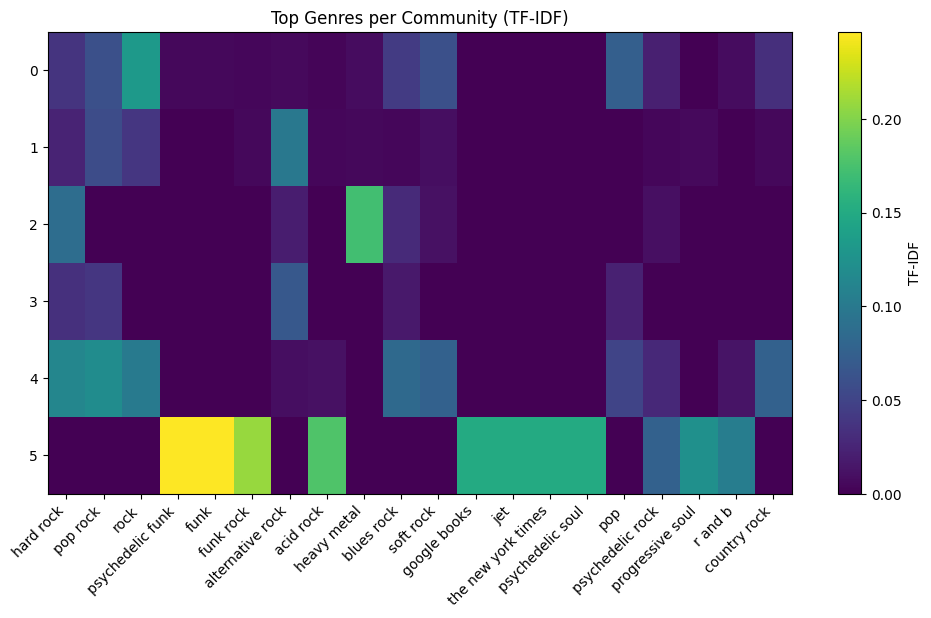

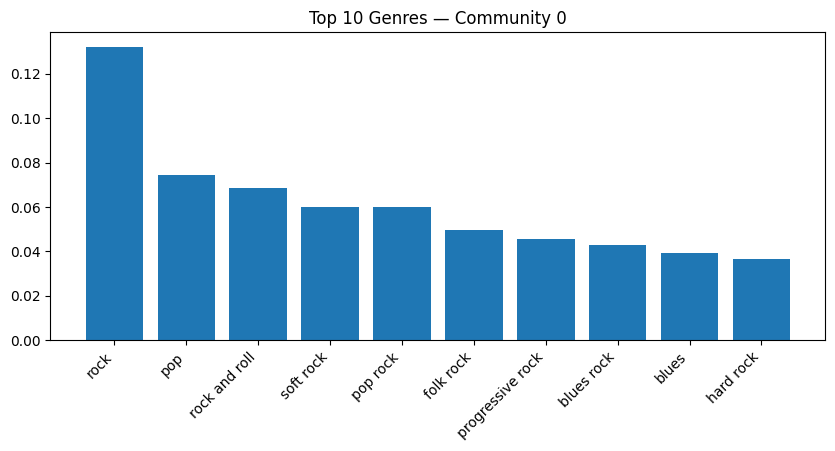

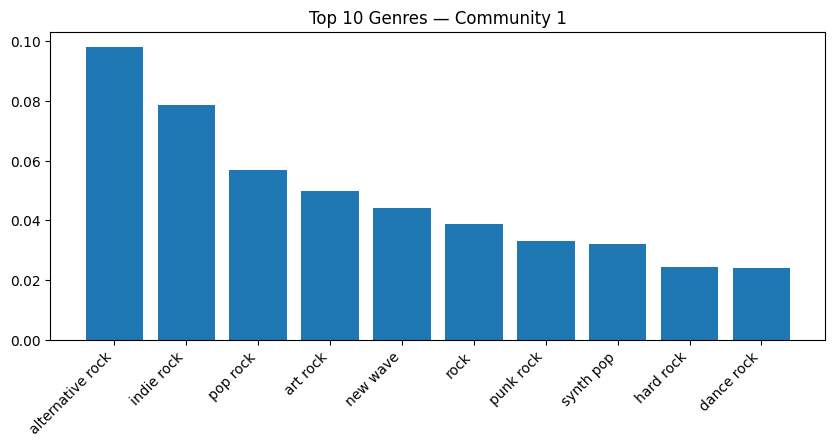

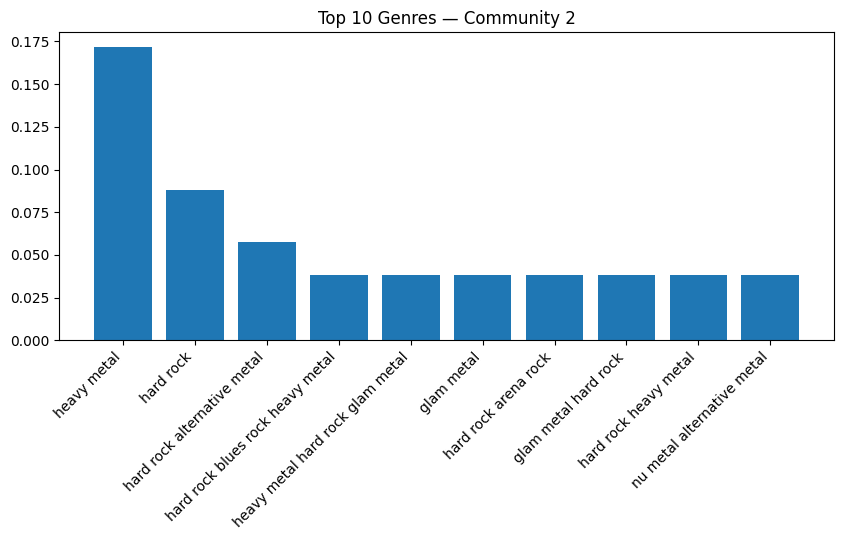

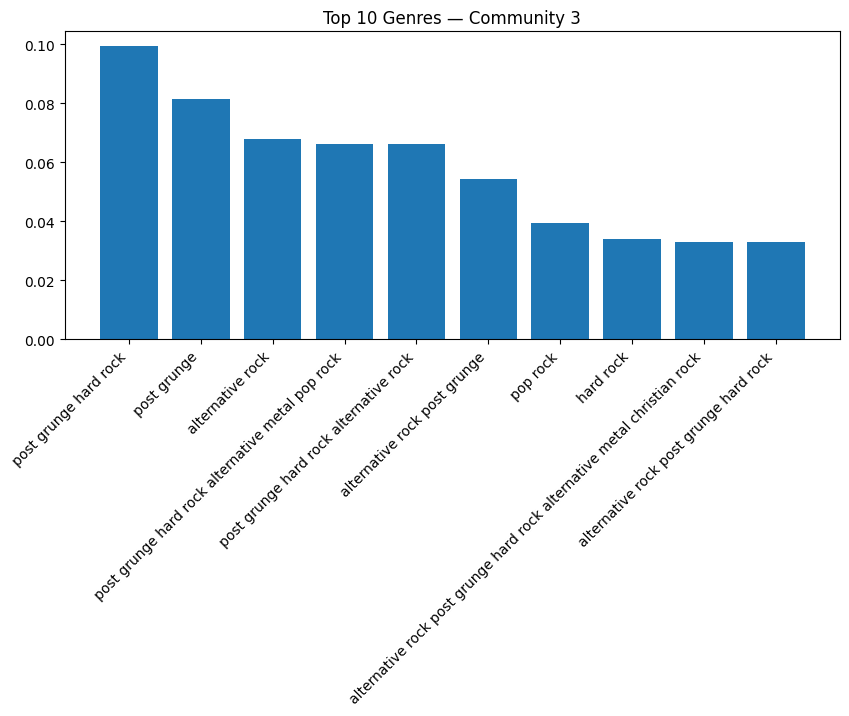

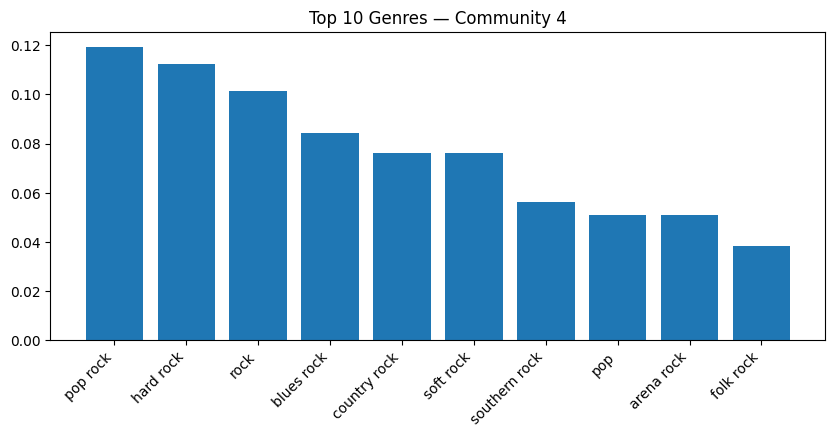

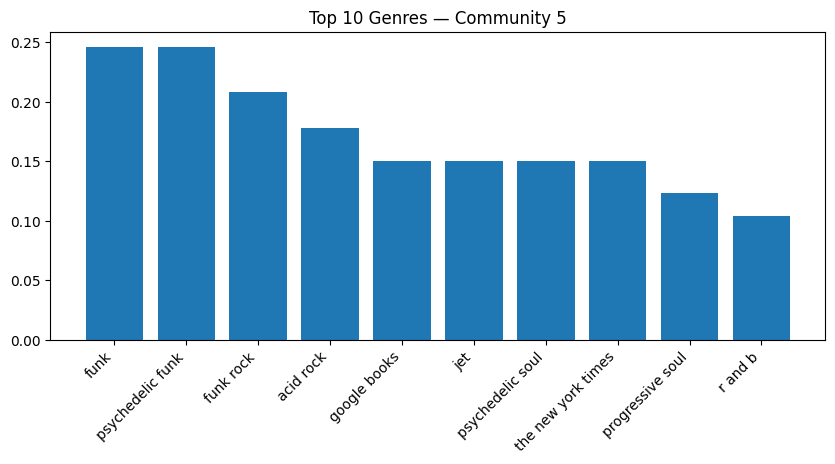

In [46]:
print(f"✅ TF-IDF complete on: {base_name}")
print(f"Detected {len(communities)} communities using {method}.\n")

for i, nodes in enumerate(communities):
    print(f"🎸 Community {i} ({len(nodes)} artists):")
    print(", ".join(nodes[:5]) + (" ..." if len(nodes) > 5 else ""))
    print()

display(df_tfidf.head())

show_heatmap(df_tfidf, top_k=20)
show_top_bars(df_tfidf, top_n=10)

# Calculate and visualize TF-IDF for the genres and communities.

Using Louvain on the artist network, we found 5 communities (sizes: 150, 147, 89, 55, 3). Running TF-IDF on node genres highlights what’s distinctive for each group rather than what’s merely popular.

The network’s structure matches genre history: classic/roots, indie/alt, heavy/metal, post-grunge/alt-metal. TF-IDF surfaces what makes each cluster unique, letting us interpret communities as stylistic neighborhoods rather than generic “popularity.”

In [50]:
for node in G.nodes():
    for key, value in G.nodes[node].items():
        if isinstance(value, list):
            G.nodes[node][key] = ";".join(value)

# Save the graph for future use
nx.write_graphml(G, "rock_network_with_communities.graphml")


# Load enriched graph
#G = nx.read_graphml("rock_network_with_communities_and_sentiment.graphml")

node_genres = {
    n: [g.strip() for g in str(G.nodes[n].get("genres", "")).split(";") if g.strip()]
    for n in G.nodes()
}

# Community assignment
# Assume each node has a "community" attribute created earlier
node_comms = {n: G.nodes[n].get("community") for n in G.nodes()}

# Count genres overall
genre_counts = Counter([g for genres in node_genres.values() for g in genres])
top_genres = [g for g, _ in genre_counts.most_common(7)]

# Count communities by size
comm_counts = Counter([c for c in node_comms.values() if c is not None])
print("Community sizes:", comm_counts.most_common(7))
top_comms = [c for c, _ in comm_counts.most_common(7)]

print("Top genres:", top_genres)
print("Top communities:", top_comms)

# Build confusion matrix
matrix = pd.DataFrame(
    0, index=top_genres, columns=top_comms, dtype=int
)

for node in G.nodes():
    comm = node_comms[node]
    genres = node_genres[node]

    if comm not in top_comms:
        continue

    # consider all genres for that node
    for g in genres:
        if g in top_genres:
            matrix.loc[g, comm] += 1

print("\nConfusion matrix (genre x community):\n")
print(matrix)

# Normalize by row (optional, to interpret purity of genres by community)
row_norm = matrix.div(matrix.sum(axis=1), axis=0)
print("\nRow-normalized version:\n")
print(row_norm.round(2))


Community sizes: [(3, 150), (1, 147), (0, 89), (2, 55), (4, 40), (5, 3)]
Top genres: ['rock', 'pop rock', 'hard rock', 'alternative rock', 'blues rock', 'soft rock', 'pop']
Top communities: [3, 1, 0, 2, 4, 5]

Confusion matrix (genre x community):

                   3   1  0  2   4  5
rock              32   7  0  0   8  0
pop rock          17  12  0  2  11  0
hard rock         12   6  9  2  12  0
alternative rock   2  24  2  4   1  0
blues rock        14   1  3  1   9  0
soft rock         17   2  1  0   7  0
pop               18   0  0  1   4  0

Row-normalized version:

                     3     1     0     2     4    5
rock              0.68  0.15  0.00  0.00  0.17  0.0
pop rock          0.40  0.29  0.00  0.05  0.26  0.0
hard rock         0.29  0.15  0.22  0.05  0.29  0.0
alternative rock  0.06  0.73  0.06  0.12  0.03  0.0
blues rock        0.50  0.04  0.11  0.04  0.32  0.0
soft rock         0.63  0.07  0.04  0.00  0.26  0.0
pop               0.78  0.00  0.00  0.04  0.17  0.0


## Use the matrix d (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

Genres group by labels; communities group by network structure, so their word‑clouds need not match. The matrix shows where to expect overlap. Alternative rock is concentrated in community 1 (0.73), so its genre cloud should closely resemble community 1. Hard rock is split across communities 3 (0.29), 4 (0.29), and 0 (0.22), and pop rock across 3 (0.40), 1 (0.29), and 4 (0.26), so their genre clouds will blend multiple community vocabularies. Community 3 is the largest (150 nodes) and dominates rock (0.68), soft rock (0.63), and pop (0.78), so these genre clouds will reflect broad, high‑frequency terms typical of community 3. Blues rock shows a mixed profile with community 3 (0.50) and 4 (0.32). So to summarize: concentrated genres align with their main community; dispersed genres produce hybrid word‑clouds. This explains why community clouds can look sharper or broader than genre clouds even when they share many artists.